# Tutorial 8: Train NicheTrans on human lymph node data

In [9]:
import os, time, datetime, warnings

import torch
import torch.nn as nn
from torch.optim import lr_scheduler

from model.nicheTrans_img import *
from datasets.data_manager_human_lymph_node import Lymph_node

from utils.utils import *
from utils.notebook_hparams import build_model_from_args
from utils.utils_training_human_lymph_node import train, test
from utils.utils_dataloader import *

warnings.filterwarnings("ignore")

### Initialize the args and fix seeds

In [10]:
%run ./args/args_human_lymph_node.py
args = args

set_seed(args.seed)
os.environ['CUDA_VISIBLE_DEVICES'] = args.gpu_devices

print("==========\nArgs:{}\n==========".format(args))

Args:Namespace(noise_rate=0.5, dropout_rate=0.1, use_moe_ffn=True, num_experts=4, moe_gate_hidden_dim=256, moe_gate_type='softmax', ffn_mult=8, moe_router_temperature_enable=True, moe_router_temperature_start=1.0, moe_router_temperature_mid=0.7, moe_router_temperature_end=0.5, moe_router_temperature_schedule='step', moe_balance_loss_enable=True, moe_balance_loss_weight=0.003, moe_balance_loss_type='mse_uniform', moe_router_entropy_penalty_enable=True, moe_router_entropy_penalty_weight=0.003, n_source=3000, workers=4, adata_path='/mnt/datadisk0/Processed_DATA/2024_nm_human_lymph_nodes/', max_epoch=20, stepsize=10, train_batch=32, test_batch=32, optimizer='adam', lr=0.0003, gamma=0.1, weight_decay=0.0005, seed=1, save_dir='./log', eval_step=1, gpu_devices='0')


### Initialize dataloaders and NicheTrans

In [11]:
# create the dataloaders
dataset = Lymph_node(adata_path=args.adata_path, n_top_genes=args.n_source)
trainloader, testloader = human_node_dataloader(args, dataset)

# create the model
source_dimension, target_dimension = dataset.rna_length, dataset.protein_length
model = build_model_from_args(NicheTrans, args, source_length=source_dimension, target_length=target_dimension)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

------Calculating spatial graph...
The graph contains 13638 edges, 3484 cells.
3.9145 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 27174 edges, 3484 cells.
7.7997 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 13138 edges, 3359 cells.
3.9113 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 26192 edges, 3359 cells.
7.7976 neighbors per cell on average.
=> Human lymph node loaded
Dataset statistics:
  ------------------------------
  subset   | # num | 
  ------------------------------
  train    |  After filting  3484 spots
  test     |  After filting  3359 spots
  ------------------------------


### Initialize loss function (criterion) and optimizer

In [12]:
criterion = nn.MSELoss()

if args.optimizer == 'adam':
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
elif args.optimizer == 'SGD':
    optimizer = torch.optim.SGD(model.parameters(), lr=args.lr)
else:
    print('unexpected optimizer')

if args.stepsize > 0:
    scheduler = lr_scheduler.StepLR(optimizer, step_size=args.stepsize, gamma=args.gamma)

### Optional MoE Trajectory Tracking During Training

Enable the next cell if you want to monitor whether expert usage becomes more balanced or more specialized across epochs.


In [13]:
from utils.moe_analysis import analyze_moe_routing, summarize_epoch_trajectory

track_moe_during_training = True
moe_track_every = 1
moe_track_max_batches = None  # Set to a small integer for faster monitoring on large datasets.
moe_epoch_frames = {}
moe_epoch_overall = []



### Model training and testing

In [14]:
start_time = time.time()

if "track_moe_during_training" not in globals():
    track_moe_during_training = True
    moe_track_every = 1
    moe_track_max_batches = None
    moe_epoch_frames = {}
    moe_epoch_overall = []

for epoch in range(args.max_epoch):
    last_epoch = epoch + 1 == args.max_epoch

    print("==> Epoch {}/{}".format(epoch+1, args.max_epoch))
    
    ################
    train(model, criterion, optimizer, trainloader, device=device)
    if args.stepsize > 0: scheduler.step()

    if track_moe_during_training and ((epoch + 1) % moe_track_every == 0 or last_epoch):
        moe_epoch_result = analyze_moe_routing(
            model=model,
            dataloader=testloader,
            device=device,
            include_images=False,
            include_cell_information=False,
            include_predictions=False,
            include_targets=False,
            max_batches=moe_track_max_batches,
            add_spatial_regions=False,
        )
        moe_epoch_frames[epoch + 1] = moe_epoch_result["activation_frame"]
        moe_epoch_overall.append({"epoch": epoch + 1, **moe_epoch_result["overall"]})
        print("MoE tracking at epoch {}:".format(epoch + 1), moe_epoch_result["overall"])
    ################
    
pearson = test(model, testloader, device=device)
torch.save(model.state_dict(), 'NicheTrans_human_lymph_node_last.pth')

elapsed = round(time.time() - start_time)
elapsed = str(datetime.timedelta(seconds=elapsed))
print("Finished. Total elapsed time (h:m:s): {}".format(elapsed))


==> Epoch 1/20
Batch 108/108	 Loss 1.291760 (0.989616) | Task 0.985458 | Aux 0.004158 | Tau 1.0000 | Bal 0.000313 | Ent 1.385589 | Margin 0.005388 | Cos 0.109041
MoE tracking at epoch 1: {'num_center_spots': 3359, 'num_experts': 4, 'usage_entropy_normalised': 0.9998602544470463, 'top1_entropy_normalised': 0.7307150303837773, 'effective_expert_count': 3.9992251611683898, 'dominant_expert_fraction': 0.2542966135815518, 'mean_weight_l1_to_uniform': 0.016409200016463538, 'balance_loss': 9.861193946164144e-05, 'top1_l1_to_uniform': 0.7331050908008336, 'mean_spot_entropy': 1.3859383692943659, 'std_spot_entropy': 0.00037136029383508316, 'mean_gate_margin': 0.0018843180209123225, 'std_gate_margin': 0.0017136905359841255, 'router_temperature': 1.0, 'router_entropy_penalty': 1.3859432070480282, 'expert_output_cosine_mean': 0.18101969203820503, 'expert_output_cosine_std': 0.0711549493254349}
==> Epoch 2/20
Batch 108/108	 Loss 0.482693 (0.890073) | Task 0.885915 | Aux 0.004158 | Tau 1.0000 | Bal 0

### Optional MoE Routing Analysis

Run the next cell after training if you want to inspect expert activation, load balance, and spatial specialization.


Overall MoE metrics:
{'num_center_spots': 3359, 'num_experts': 4, 'usage_entropy_normalised': 0.22652445145447533, 'top1_entropy_normalised': 0.1490835381221069, 'effective_expert_count': 1.3689302148144211, 'dominant_expert_fraction': 0.9343405895691501, 'mean_weight_l1_to_uniform': 1.3686811782945298, 'balance_loss': 0.6238946175248753, 'top1_l1_to_uniform': 1.422000595415302, 'mean_spot_entropy': 0.16326249225701084, 'std_spot_entropy': 0.3481962272205316, 'mean_gate_margin': 0.9139878062161004, 'std_gate_margin': 0.23486280687596858, 'router_temperature': 0.5, 'router_entropy_penalty': 0.16824827067959908, 'expert_output_cosine_mean': 0.6578386724616275, 'expert_output_cosine_std': 0.1702993007670133}


,expert,average_activation_weight,top1_selection_frequency
0,0,0.025138,0.013992
1,1,0.020794,0.009229
2,2,0.934341,0.961000
3,3,0.019728,0.015779


,slice_id,expert_0_mean_weight,expert_1_mean_weight,expert_2_mean_weight,expert_3_mean_weight,expert_0_top1_frequency,expert_1_top1_frequency,expert_2_top1_frequency,expert_3_top1_frequency,num_center_spots,...,balance_loss,top1_l1_to_uniform,mean_spot_entropy,std_spot_entropy,mean_gate_margin,std_gate_margin,router_temperature,router_entropy_penalty,expert_output_cosine_mean,expert_output_cosine_std
0,default,0.025138,0.020794,0.934341,0.019728,0.013992,0.009229,0.961,0.015779,3359,...,0.623895,1.422001,0.163262,0.348196,0.913988,0.234863,0.5,0.168248,0.657839,0.170299


,spatial_region,expert_0_mean_weight,expert_1_mean_weight,expert_2_mean_weight,expert_3_mean_weight,expert_0_top1_frequency,expert_1_top1_frequency,expert_2_top1_frequency,expert_3_top1_frequency,num_center_spots,...,balance_loss,top1_l1_to_uniform,mean_spot_entropy,std_spot_entropy,mean_gate_margin,std_gate_margin,router_temperature,router_entropy_penalty,expert_output_cosine_mean,expert_output_cosine_std
0,default|x0_y0,0.034586,0.028156,0.910842,0.026416,0.021978,0.013187,0.946154,0.018681,910,...,0.620156,1.392308,0.222377,0.385791,0.883624,0.261659,0.5,0.172728,0.657203,0.170384
1,default|x0_y1,0.045754,0.041805,0.871819,0.040622,0.029870,0.022078,0.903896,0.044156,770,...,0.621615,1.307792,0.270204,0.470263,0.837479,0.331556,0.5,0.169700,0.659064,0.169198
2,default|x1_y0,0.013569,0.009478,0.968311,0.008642,0.003896,0.002597,0.992208,0.001299,770,...,0.624630,1.484416,0.102088,0.247981,0.955417,0.150443,0.5,0.167691,0.657477,0.171250
3,default|x1_y1,0.008017,0.005210,0.982050,0.004724,0.001100,0.000000,0.997800,0.001100,909,...,0.628946,1.495600,0.065314,0.183431,0.974101,0.109779,0.5,0.163006,0.657743,0.170341


,sample_id,slice_id,spot_id,x,y,batch_index,batch_spot_index,top1_expert,top1_weight,center_entropy,...,target_22,target_23,target_24,target_25,target_26,target_27,target_28,target_29,target_30,spatial_region
0,14_0,default,14_0,14.0,0.0,51,18,2,0.990697,0.061413,...,0.085699,0.184208,0.332505,1.297080,0.601530,1.003018,0.196651,0.449594,0.986500,default|x0_y0
1,16_0,default,16_0,16.0,0.0,54,13,2,0.996735,0.024842,...,0.112855,-2.057792,-1.299184,0.014043,-0.773163,-0.076710,-2.354436,-0.976474,-0.086805,default|x0_y0
2,18_0,default,18_0,18.0,0.0,10,14,2,0.987558,0.078908,...,0.759769,0.193185,0.750456,0.657912,0.422595,0.727902,-0.004481,0.175593,0.472729,default|x0_y0
3,20_0,default,20_0,20.0,0.0,2,15,2,0.992625,0.050443,...,0.572739,-0.263944,0.233377,0.120309,0.369121,-1.205086,0.073081,-0.042643,0.270023,default|x0_y0
4,22_0,default,22_0,22.0,0.0,95,7,2,0.993241,0.046825,...,0.400436,0.213515,0.246174,0.393011,0.127433,0.046691,0.188135,0.327717,0.254237,default|x0_y0


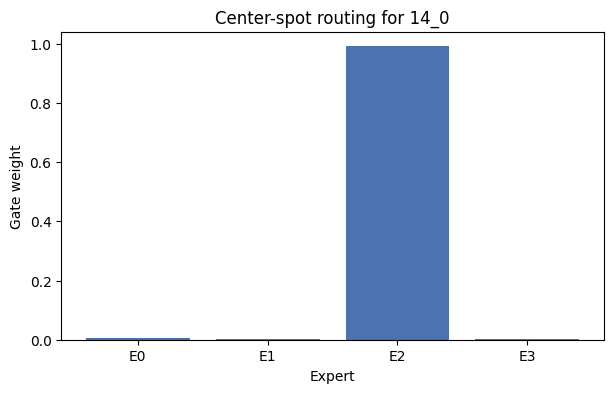

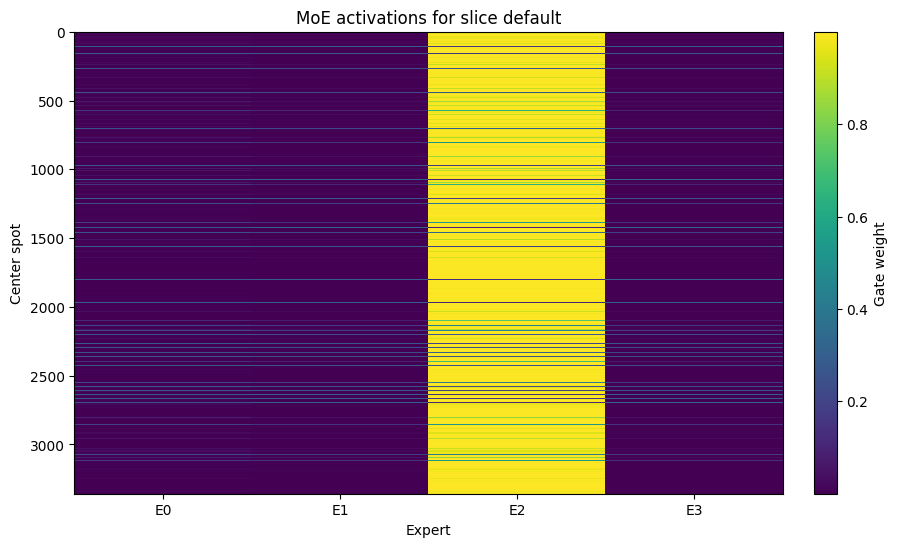

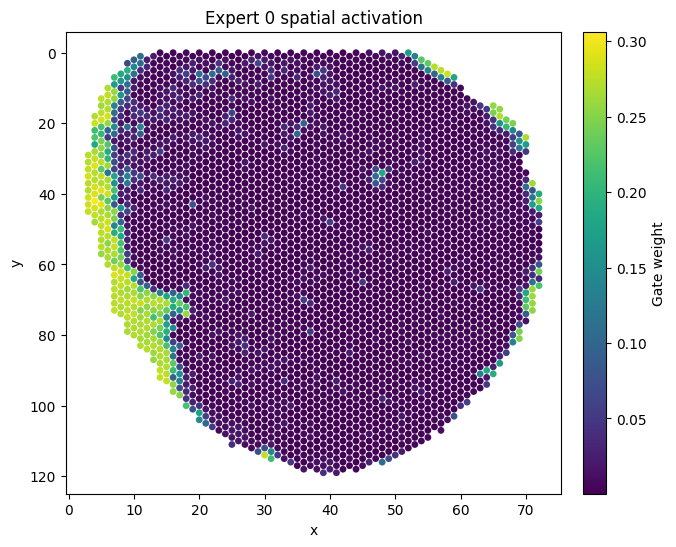

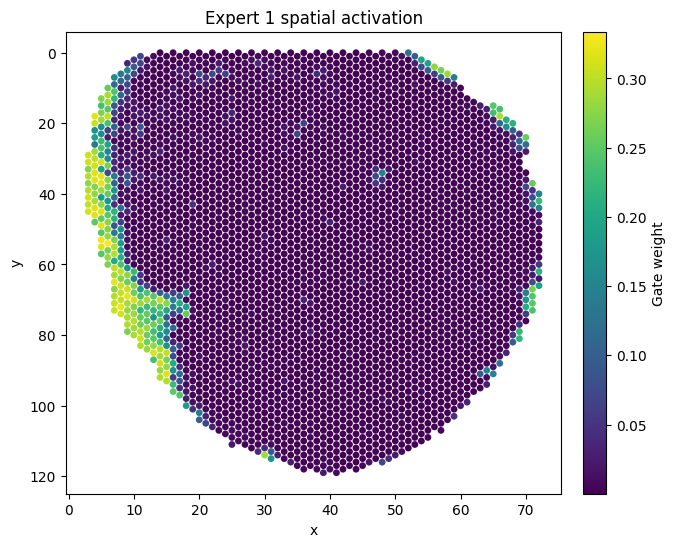

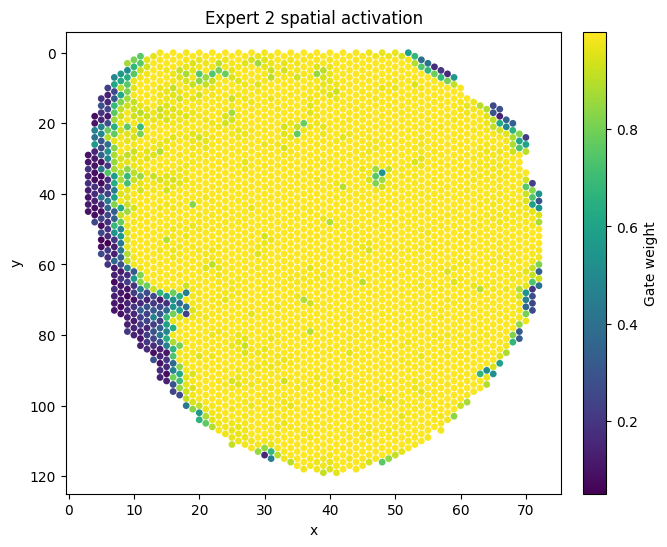

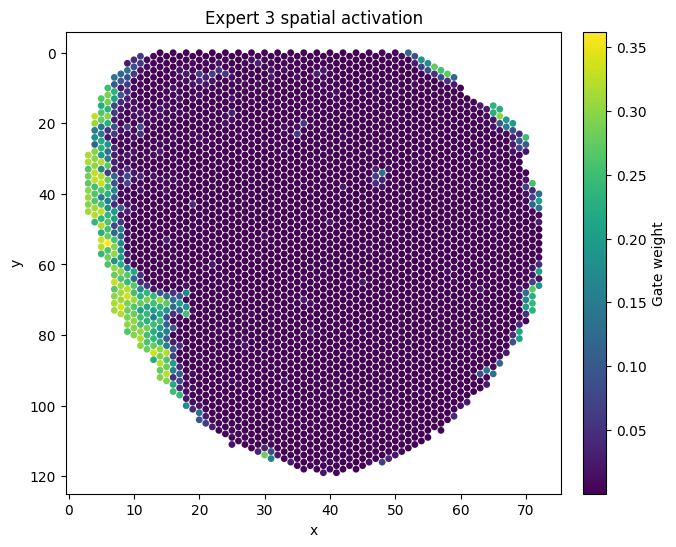

In [15]:
from utils.moe_analysis import (
    analyze_moe_routing,
    plot_center_spot_activation_bar,
    plot_expert_spatial_heatmap,
    plot_slice_activation_heatmap,
    save_moe_analysis_tables,
)

moe_results = analyze_moe_routing(
    model=model,
    dataloader=testloader,
    device=device,
    include_images=False,
    include_cell_information=False,
    include_predictions=False,
    include_targets=True,
)

activation_frame = moe_results["activation_frame"]

print("Overall MoE metrics:")
print(moe_results["overall"])
display(moe_results["expert_summary"])
if not moe_results["slice_summary"].empty:
    display(moe_results["slice_summary"])
if not moe_results["region_summary"].empty:
    display(moe_results["region_summary"])

display(activation_frame.head())
plot_center_spot_activation_bar(activation_frame, row_index=0);

if activation_frame["x"].notna().any() and activation_frame["y"].notna().any():
    first_slice = activation_frame["slice_id"].dropna().iloc[0]
    plot_slice_activation_heatmap(activation_frame, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=0, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=1, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=2, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=3, slice_id=first_slice);

else:
    print(
        "Spatial coordinates were not recovered from the sample ids. "
        "Pass `sample_metadata_resolver` to `analyze_moe_routing(...)` if you want spatial heatmaps."
    )

# Optional: save the analysis tables to disk.
# save_moe_analysis_tables(moe_results, output_dir="./moe_analysis")



### Optional MoE Training Trajectory Summary

If epoch-level tracking was enabled during training, the next cell summarizes how expert usage changed over time.


,epoch,num_center_spots,num_experts,usage_entropy_normalised,top1_entropy_normalised,effective_expert_count,dominant_expert_fraction,mean_weight_l1_to_uniform,balance_loss,top1_l1_to_uniform,mean_spot_entropy,std_spot_entropy,mean_gate_margin,std_gate_margin,router_temperature,router_entropy_penalty,expert_output_cosine_mean,expert_output_cosine_std
0,1,3359,4,0.999860,7.307150e-01,3.999225,0.254297,0.016409,0.000099,0.733105,1.385938,0.000371,0.001884,0.001714,1.0,1.385943,0.181020,0.071155
1,2,3359,4,0.999879,5.938333e-01,3.999327,0.254085,0.016118,0.000086,0.927955,1.386081,0.000155,0.001174,0.000780,1.0,1.386081,0.270406,0.117974
2,3,3359,4,0.999981,5.359466e-01,3.999892,0.251555,0.006072,0.000014,0.980351,1.386252,0.000030,0.001489,0.001082,1.0,1.386252,0.291914,0.110995
3,4,3359,4,0.999979,6.097315e-01,3.999884,0.251438,0.006538,0.000015,0.839238,1.386262,0.000016,0.000396,0.000213,1.0,1.386262,0.412059,0.145135
4,5,3359,4,0.999953,3.382016e-01,3.999740,0.252476,0.009634,0.000033,1.143346,1.386227,0.000019,0.001145,0.000857,0.7,1.386226,0.486711,0.151485
5,6,3359,4,0.999917,5.979471e-11,3.999538,0.254236,0.012272,0.000058,1.500000,1.386179,0.000003,0.003061,0.000173,0.7,1.386179,0.394930,0.161601
6,7,3359,4,0.999716,5.979471e-11,3.998428,0.257535,0.024444,0.000195,1.500000,1.385901,0.000025,0.002848,0.000273,0.7,1.385901,0.375070,0.218608
7,8,3359,4,0.999686,5.979471e-11,3.998260,0.259371,0.024143,0.000217,1.500000,1.385859,0.000017,0.006671,0.000266,0.7,1.385859,0.540722,0.207101
8,9,3359,4,0.999575,5.979471e-11,3.997642,0.260395,0.029930,0.000294,1.500000,1.385704,0.000013,0.005825,0.000650,0.7,1.385703,0.563624,0.224896
9,10,3359,4,0.286639,1.600992e-01,1.487900,0.910550,1.321100,0.582550,1.413665,0.240055,0.380256,0.876292,0.254968,0.5,0.243969,0.635369,0.176241


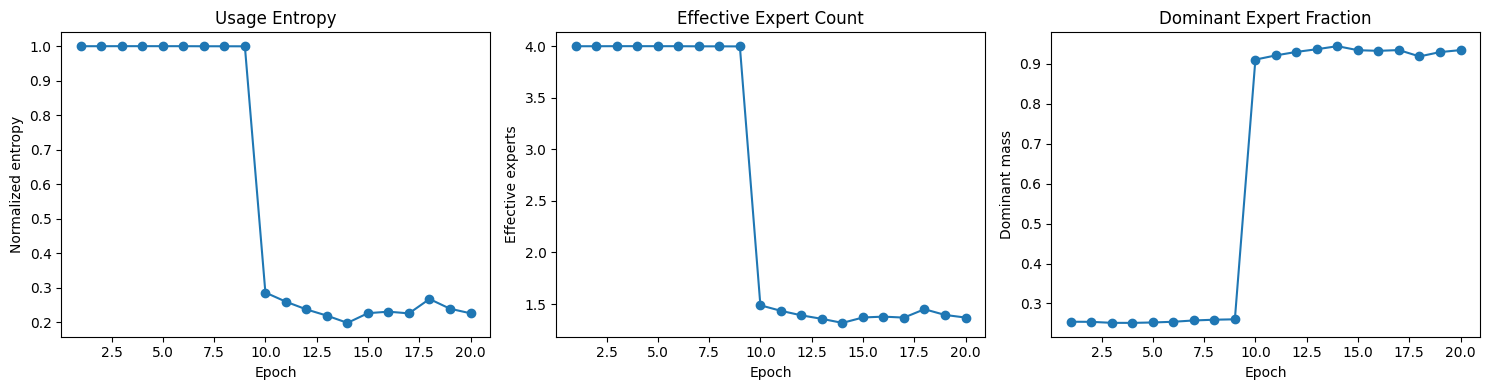

In [16]:
import matplotlib.pyplot as plt

if not moe_epoch_frames:
    print(
        "No epoch-level MoE trajectory was recorded. "
        "Set `track_moe_during_training = True` before training and rerun the notebook if you want this summary."
    )
else:
    moe_epoch_trajectory = summarize_epoch_trajectory(moe_epoch_frames)
    display(moe_epoch_trajectory)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(moe_epoch_trajectory["epoch"], moe_epoch_trajectory["usage_entropy_normalised"], marker="o")
    axes[0].set_title("Usage Entropy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Normalized entropy")

    axes[1].plot(moe_epoch_trajectory["epoch"], moe_epoch_trajectory["effective_expert_count"], marker="o")
    axes[1].set_title("Effective Expert Count")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Effective experts")

    axes[2].plot(moe_epoch_trajectory["epoch"], moe_epoch_trajectory["dominant_expert_fraction"], marker="o")
    axes[2].set_title("Dominant Expert Fraction")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Dominant mass")

    plt.tight_layout()

# Optional: save the trajectory table to disk.
# moe_epoch_trajectory.to_csv("./moe_analysis/moe_epoch_trajectory.csv", index=False)

